# Ứng dụng NLP trong phân tích cảm xúc đánh giá sản phẩm tiếng Việt

Notebook này xây dựng pipeline thực nghiệm cho bài toán phân loại cảm xúc đánh giá sản phẩm tiếng Việt với 3 mô hình:

- **SVM + TF-IDF**
- **BiLSTM + Word Embedding**
- **PhoBERT fine-tuning với CUDA/GPU**

Dataset gồm các cột chính:

| Cột | Ý nghĩa |
|---|---|
| `content` | Nội dung đánh giá sản phẩm |
| `label` | Nhãn cảm xúc: POS, NEG, NEU |
| `start` | Số sao đánh giá |

## 1. Cài đặt và import thư viện

In [1]:
# Nếu thiếu thư viện, chạy các lệnh sau:
!pip install pyvi joblib tqdm
!pip install torch transformers emoji

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import re
import random
import joblib
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import emoji
except ImportError:
    emoji = None
    print("Chưa cài thư viện emoji. Nếu cần xử lý emoji Unicode, hãy chạy: !pip install emoji")

from tqdm import tqdm
from pyvi import ViTokenizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification

## 2. Cấu hình thực nghiệm và CUDA

Phần này dùng để cố định seed và kiểm tra thiết bị huấn luyện.
Nếu máy có GPU NVIDIA và cài CUDA đúng, `device` sẽ là `cuda`.

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Thiết bị đang sử dụng:", device)

if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))
    print("Số lượng GPU:", torch.cuda.device_count())

Thiết bị đang sử dụng: cuda
Tên GPU: Tesla T4
Số lượng GPU: 1


## 3. Load dữ liệu

In [5]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/data.csv"

df = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (31460, 3)


,content,label,start
0,Áo bao đẹp ạ!,POS,5
1,Tuyệt vời,POS,5
2,2day ao khong giong trong,NEG,1
3,"Mùi thơm,bôi lên da mềm da",POS,5
4,"Vải đẹp, dày dặn",POS,5


## 4. Đọc và kiểm tra dữ liệu

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31460 entries, 0 to 31459
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  31436 non-null  object
 1   label    31460 non-null  object
 2   start    31460 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 737.5+ KB


In [7]:
df = df.rename(columns={"content": "text"})

In [8]:
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum())

print("\nSố dòng trùng lặp:", df["text"].astype(str).duplicated().sum())

Số giá trị thiếu theo từng cột:
text     24
label     0
start     0
dtype: int64

Số dòng trùng lặp: 4943


Phân bố nhãn cảm xúc:
label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


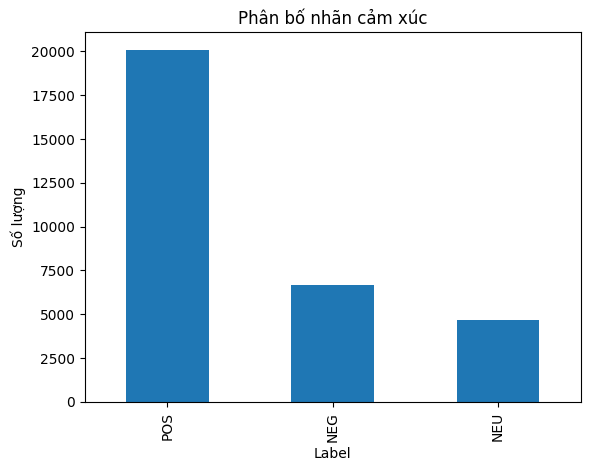

In [9]:
print("Phân bố nhãn cảm xúc:")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Phân bố nhãn cảm xúc")
plt.xlabel("Label")
plt.ylabel("Số lượng")
plt.show()

Phân bố số sao:
start
1     3529
2     3140
3     4698
4     6807
5    13286
Name: count, dtype: int64


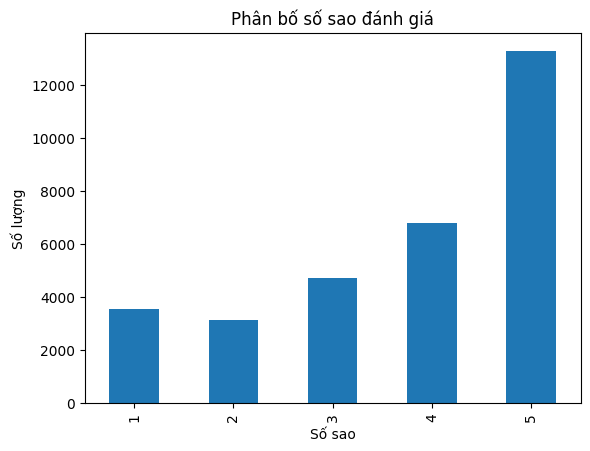

In [10]:
print("Phân bố số sao:")
print(df["start"].value_counts().sort_index())

df["start"].value_counts().sort_index().plot(kind="bar")
plt.title("Phân bố số sao đánh giá")
plt.xlabel("Số sao")
plt.ylabel("Số lượng")
plt.show()

Kiểm tra duplicate và nhãn mâu thuẫn
Các dòng trùng text có thể làm rò rỉ dữ liệu giữa train/val/test. Đặc biệt, cùng một text nhưng nhiều nhãn khác nhau là tín hiệu lỗi gán nhãn.

In [11]:
df["text_str"] = df["text"].astype(str).str.strip()

duplicate_all = df[df["text_str"].duplicated(keep=False)].sort_values("text_str")
print("Tất cả các hàng trùng lặp:", duplicate_all.shape)
duplicate_all.head(10)

Tất cả các hàng trùng lặp: (5868, 4)


,text,label,start,text_str
10802,:),POS,4,:)
21345,:),NEU,3,:)
19253,:),NEU,3,:)
25417,:),NEU,3,:)
9620,:),NEU,3,:)
11470,:))),NEG,1,:)))
23484,:))),NEU,3,:)))
6593,<3,NEU,3,<3
14737,<3,POS,5,<3
24771,<3,POS,5,<3


In [12]:
conflict_texts = (
    df.groupby("text_str")["label"]
    .nunique()
    .reset_index(name="n_labels")
    .query("n_labels > 1")
)
print("Số lượng văn bản trùng lặp có nhãn xung đột:", len(conflict_texts))

df_conflict = df[df["text_str"].isin(conflict_texts["text_str"])].sort_values("text_str")
df_conflict.head(20)

Số lượng văn bản trùng lặp có nhãn xung đột: 277


,text,label,start,text_str
9620,:),NEU,3,:)
19253,:),NEU,3,:)
21345,:),NEU,3,:)
10802,:),POS,4,:)
25417,:),NEU,3,:)
23484,:))),NEU,3,:)))
11470,:))),NEG,1,:)))
24771,<3,POS,5,<3
6593,<3,NEU,3,<3
14737,<3,POS,5,<3


## 5. Làm sạch dữ liệu ban đầu

Chiến lược xử lý duplicate:

- Loại bỏ dòng thiếu text hoặc label.
- Chuẩn hóa text thô về chuỗi.
- Với text trùng nhưng nhãn không mâu thuẫn: giữ một dòng.
- Với text trùng nhưng nhãn mâu thuẫn: loại bỏ để tránh nhiễu nhãn trong bài thực hành.

In [13]:
df_clean = df[["text", "label"]].copy()
df_clean = df_clean.dropna(subset=["text", "label"])
df_clean["text"] = df_clean["text"].astype(str).str.strip()
df_clean = df_clean[df_clean["text"].str.len() > 0]

# Loại các text có nhãn mâu thuẫn.
conflict_set = set(conflict_texts["text_str"].tolist())
df_clean = df_clean[~df_clean["text"].isin(conflict_set)].copy()

# Loại duplicate còn lại.
df_clean = df_clean.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)

print("Before:", df.shape)
print("After:", df_clean.shape)
print(df_clean["label"].value_counts())
df_clean.head()

Before: (31460, 4)
After: (26240, 2)
label
POS    15863
NEG     6256
NEU     4121
Name: count, dtype: int64


,text,label
0,Áo bao đẹp ạ!,POS
1,Tuyệt vời,POS
2,2day ao khong giong trong,NEG
3,"Mùi thơm,bôi lên da mềm da",POS
4,"Vải đẹp, dày dặn",POS


## 6. Phân tích độ dài văn bản

In [14]:
df_clean["text_length"] = df_clean["text"].astype(str).apply(lambda x: len(x.split()))

df_clean.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
NEG,6256.0,10.504316,8.433934,1.0,5.0,8.0,13.0,74.0
NEU,4121.0,9.672652,6.721459,1.0,5.0,8.0,12.0,65.0
POS,15863.0,11.694446,9.543911,1.0,5.0,9.0,15.0,74.0


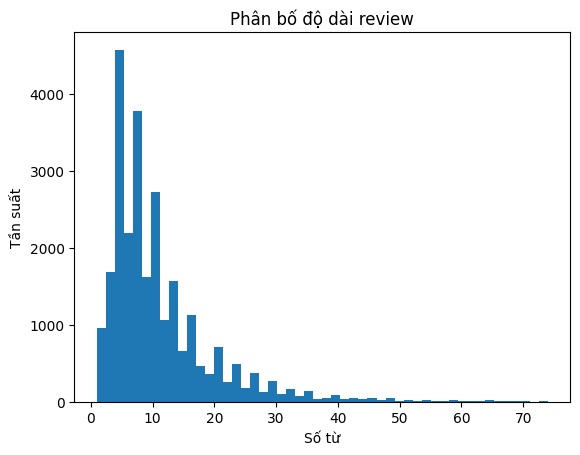

In [15]:
df_clean["text_length"].plot(kind="hist", bins=50)
plt.title("Phân bố độ dài review")
plt.xlabel("Số từ")
plt.ylabel("Tần suất")
plt.show()

## 7. Mã hóa nhãn

In [16]:
label2id = {
    "NEG": 0,
    "NEU": 1,
    "POS": 2
}

id2label = {
    0: "NEG",
    1: "NEU",
    2: "POS"
}

df_clean["label_id"] = df_clean["label"].map(label2id)

df_clean[["text", "label", "label_id"]].head()

,text,label,label_id
0,Áo bao đẹp ạ!,POS,2
1,Tuyệt vời,POS,2
2,2day ao khong giong trong,NEG,0
3,"Mùi thơm,bôi lên da mềm da",POS,2
4,"Vải đẹp, dày dặn",POS,2


## 8. Tiền xử lý dữ liệu tiếng Việt

Phần này thực hiện các bước:

1. Chuẩn hóa Unicode.
2. Chuyển chữ thường.
3. Chuẩn hóa emoji/emoticon thành token cảm xúc.
4. Chuẩn hóa từ viết tắt phổ biến trong review tiếng Việt.
5. Xử lý ký tự lặp.
6. Xử lý **Negation & phrase handling**:
   - Phủ định thông thường: `không tốt` → `không_tốt`.
   - Cụm phủ định mang nghĩa tích cực: `miễn chê`, `không tệ` → `POS_PHRASE`.
   - Cụm phủ định/ý định tiêu cực: `không nên mua`, `đừng mua` → `NEG_PHRASE`.
7. Tách từ tiếng Việt bằng PyVi.

In [17]:
ABBREVIATION_MAP = {
    # phủ định
    "ko": "không", "k": "không", "kh": "không", "kg": "không", "khg": "không",
    "hok": "không", "hong": "không", "hông": "không", "hem": "không", "0": "không",
    "chả": "chẳng", "chẵng": "chẳng",

    # thông dụng
    "dc": "được", "đc": "được", "đx": "được", "okie": "ok", "oke": "ok", "okela": "ok",
    "sp": "sản phẩm", "mn": "mọi người", "mng": "mọi người", "mk": "mình",
    "mik": "mình", "mềnh": "mình", "tui": "tôi", "vs": "với", "v": "vậy",
    "r": "rồi", "ùi": "rồi", "lun": "luôn", "luônn": "luôn", "ntn": "như thế nào",
    "j": "gì", "z": "vậy", "zậy": "vậy", "wa": "quá", "wá": "quá", "qua": "quá",
    "qá": "quá", "rat": "rất", "rât": "rất", "bt": "bình thường", "bth": "bình thường",
    "bthg": "bình thường", "sd": "sử dụng", "xài": "dùng",

    # cảm xúc tích cực/tiêu cực/slang
    "ngonvl": "rất ngon", "ngon_vl": "rất ngon", "đỉnhvl": "rất tốt", "xịn": "tốt",
    "chánvl": "rất chán", "tệvl": "rất tệ", "vl": "rất", "vcl": "rất", "vc": "rất",
    "cute": "dễ thương", "iu": "yêu", "iuu": "yêu",
}

POSITIVE_EMOTICONS = {
    ":)", ":-)", ":d", ":D", "=)", "^^", "^_^", ":3", ";)", ";-)", "<3",
    "😍", "🥰", "😘", "😊", "😄", "😁", "😆", "👍", "👌", "❤️", "❤", "💯", "🌟", "⭐",
}

NEGATIVE_EMOTICONS = {
    ":(", ":-(", ":'(", "=（", ":/", ":- /", "😢", "😭", "😞", "😔", "😡", "🤬", "👎", "💔", "😒",
}

POS_TOKEN = " EMO_POS "
NEG_TOKEN = " EMO_NEG "

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", str(text))


def reduce_repeated_chars(text: str) -> str:
    # Giảm ký tự lặp quá nhiều: ngonnnn -> ngonn, đẹpppp -> đẹpp
    return re.sub(r"(.)\1{2,}", r"\1\1", text)


def normalize_emojis_and_icons(text: str) -> str:
    # Thay emoticon ASCII trước.
    lowered = text
    for emo in sorted(POSITIVE_EMOTICONS, key=len, reverse=True):
        if emo in lowered:
            lowered = lowered.replace(emo, POS_TOKEN)
    for emo in sorted(NEGATIVE_EMOTICONS, key=len, reverse=True):
        if emo in lowered:
            lowered = lowered.replace(emo, NEG_TOKEN)

    # Xử lý emoji Unicode còn lại bằng emoji package.
    if emoji is None:
        return lowered

    chars = []
    for ch in lowered:
        if ch in emoji.EMOJI_DATA:
            if ch in POSITIVE_EMOTICONS:
                chars.append(POS_TOKEN)
            elif ch in NEGATIVE_EMOTICONS:
                chars.append(NEG_TOKEN)
            else:
                chars.append(" EMO_UNK ")
        else:
            chars.append(ch)
    return "".join(chars)


def normalize_abbreviations(text: str) -> str:
    tokens = text.split()
    norm_tokens = []
    for tok in tokens:
        tok_clean = tok.strip()
        norm_tokens.append(ABBREVIATION_MAP.get(tok_clean, tok_clean))
    return " ".join(norm_tokens)


def basic_clean_text(text: str) -> str:
    text = normalize_unicode(text)
    text = text.lower()
    text = normalize_emojis_and_icons(text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"\b\d{9,12}\b", " PHONE ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = reduce_repeated_chars(text)

    # Tách dấu câu để giữ tín hiệu cảm xúc thay vì xóa toàn bộ.
    text = re.sub(r"([!?.,;:()\[\]{}])", r" \1 ", text)

    # Giữ chữ, số, tiếng Việt, underscore và một số dấu câu/token.
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ_!?.,;:()\[\]{}\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_abbreviations(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


sample_texts = [
    "Máy đẹp quá!!! giao hàng nhanhhh :D",
    "Ko tốt lắm, pin tụt nhanh :( ",
    "Dùng miễn chê luôn <3",
]

for s in sample_texts:
    print("RAW       :", s)
    print("BASIC     :", basic_clean_text(s))
    # print("NEGATION  :", handle_negation(basic_clean_text(s)))
    # print("TOKENIZED :", preprocess_text(s))
    print()


RAW       : Máy đẹp quá!!! giao hàng nhanhhh :D
BASIC     : máy đẹp quá ! ! giao hàng nhanhh EMO_POS

RAW       : Ko tốt lắm, pin tụt nhanh :( 
BASIC     : không tốt lắm , pin tụt nhanh EMO_NEG

RAW       : Dùng miễn chê luôn <3
BASIC     : dùng miễn chê luôn EMO_POS



In [18]:
# Cụm đặc biệt: cần xử lý trước phủ định thông thường.
POSITIVE_PHRASES = [
    "miễn chê",
    "khỏi chê",
    "không chê vào đâu được",
    "không có gì để chê",
    "không tệ",
    "không tồi",
    "chưa bao giờ thất vọng",
    "không thất vọng",
]

NEGATIVE_PHRASES = [
    "không nên mua",
    "đừng mua",
    "không đáng tiền",
    "không hài lòng",
    "không ưng",
    "không ổn",
    "không dùng được",
    "chưa dùng đã hỏng",
]

NEGATION_WORDS = {"không", "chưa", "chẳng", "chả", "đừng", "khỏi"}
PUNCTUATIONS = {".", ",", "!", "?", ";", ":", "(", ")", "[", "]", "{", "}"}

# def replace_special_phrases(text: str) -> str:
#     """Thay các cụm đặc biệt bằng POS_PHRASE hoặc NEG_PHRASE."""
#     # Xử lý cụm dài trước để tránh thay một phần cụm.
#     for phrase in sorted(POSITIVE_PHRASES, key=len, reverse=True):
#         pattern = r"\b" + re.escape(phrase) + r"\b"
#         text = re.sub(pattern, " POS_PHRASE ", text)
#     for phrase in sorted(NEGATIVE_PHRASES, key=len, reverse=True):
#         pattern = r"\b" + re.escape(phrase) + r"\b"
#         text = re.sub(pattern, " NEG_PHRASE ", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text

def handle_negation(text: str, window: int = 2) -> str:
    """
    Ghép từ phủ định với một số token phía sau.
    Ví dụ: không tốt -> không_tốt, chưa ổn lắm -> chưa_ổn_lắm.
    """
    # text = replace_special_phrases(text)
    tokens = text.split()
    result = []
    i = 0

    while i < len(tokens):
        tok = tokens[i]
        if tok in NEGATION_WORDS:
            phrase_tokens = [tok]
            j = i + 1
            steps = 0

            while j < len(tokens) and steps < window:
                if tokens[j] in PUNCTUATIONS:
                    break
                phrase_tokens.append(tokens[j])
                j += 1
                steps += 1

            if len(phrase_tokens) > 1:
                result.append("_".join(phrase_tokens))
                i = j
            else:
                result.append(tok)
                i += 1
        else:
            result.append(tok)
            i += 1
    return " ".join(result)

def word_segment(text: str) -> str:
    return ViTokenizer.tokenize(text)


def preprocess_text(text: str) -> str:
    text = basic_clean_text(text)
    text = handle_negation(text, window=2)
    text = word_segment(text)
    return text

sample_texts = [
    "Máy đẹp quá!!! giao hàng nhanhhh :D",
    "Ko tốt lắm, pin tụt nhanh :( ",
    "Dùng miễn chê luôn <3",
    "Sản phẩm không tệ, shop đóng gói ổn",
    "Không chê vào đâu được",
    "Không nên mua, pin không tốt",
]

for s in sample_texts:
    print("RAW       :", s)
    print("NEGATION  :", handle_negation(basic_clean_text(s)))
    print("TOKENIZED :", preprocess_text(s))
    print()

# Áp dụng cho dữ liệu chính.
df_clean["clean_text"] = df_clean["text"].apply(basic_clean_text)
df_clean["negation_text"] = df_clean["clean_text"].apply(handle_negation)
df_clean["tokenized_text"] = df_clean["negation_text"].apply(word_segment)
df_clean[["text", "clean_text", "negation_text", "tokenized_text", "label"]].head()


RAW       : Máy đẹp quá!!! giao hàng nhanhhh :D
NEGATION  : máy đẹp quá ! ! giao hàng nhanhh EMO_POS
TOKENIZED : máy đẹp quá ! ! giao hàng nhanhh EMO_POS

RAW       : Ko tốt lắm, pin tụt nhanh :( 
NEGATION  : không_tốt_lắm , pin tụt nhanh EMO_NEG
TOKENIZED : không_tốt_lắm , pin tụt nhanh EMO_NEG

RAW       : Dùng miễn chê luôn <3
NEGATION  : dùng miễn chê luôn EMO_POS
TOKENIZED : dùng miễn chê luôn EMO_POS

RAW       : Sản phẩm không tệ, shop đóng gói ổn
NEGATION  : sản phẩm không_tệ , shop đóng gói ổn
TOKENIZED : sản_phẩm không_tệ , shop đóng_gói ổn

RAW       : Không chê vào đâu được
NEGATION  : không_chê_vào đâu được
TOKENIZED : không_chê_vào đâu được

RAW       : Không nên mua, pin không tốt
NEGATION  : không_nên_mua , pin không_tốt
TOKENIZED : không_nên_mua , pin không_tốt



,text,clean_text,negation_text,tokenized_text,label
0,Áo bao đẹp ạ!,áo bao đẹp ạ !,áo bao đẹp ạ !,áo bao đẹp ạ !,POS
1,Tuyệt vời,tuyệt vời,tuyệt vời,tuyệt_vời,POS
2,2day ao khong giong trong,2day ao khong giong trong,2day ao khong giong trong,2day ao khong giong trong,NEG
3,"Mùi thơm,bôi lên da mềm da","mùi thơm , bôi lên da mềm da","mùi thơm , bôi lên da mềm da","mùi thơm , bôi lên da mềm da",POS
4,"Vải đẹp, dày dặn","vải đẹp , dày dặn","vải đẹp , dày dặn","vải đẹp , dày_dặn",POS


## 9. Chia tập train/test/validation

Sử dụng `stratify=y` để giữ tỷ lệ nhãn giữa tập train, validation và test.

In [30]:
X = df_clean["tokenized_text"]
y = df_clean["label_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nPhân bố nhãn train:")
print(y_train.value_counts(normalize=True))

print("\nPhân bố nhãn test:")
print(y_test.value_counts(normalize=True))

Train size: (20992,)
Test size: (5248,)

Phân bố nhãn train:
label_id
2    0.604516
0    0.238424
1    0.157060
Name: proportion, dtype: float64

Phân bố nhãn test:
label_id
2    0.604611
0    0.238377
1    0.157012
Name: proportion, dtype: float64


# Phần A — Mô hình SVM + TF-IDF

## 10. Huấn luyện SVM

Pipeline:

```text
Text đã tách từ
→ TF-IDF
→ Linear SVM
→ Dự đoán cảm xúc
```

In [31]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2)
    )),
    ("svm", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)
print("Huấn luyện SVM hoàn tất.")

Huấn luyện SVM hoàn tất.


## 11. Đánh giá SVM

In [32]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {model_name} =====")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["NEG", "NEU", "POS"]
    ))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NEG", "NEU", "POS"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

===== SVM + TF-IDF =====
Accuracy : 0.7559070121951219
Precision: 0.7536731528850854
Recall   : 0.7559070121951219
F1-score : 0.7543483431528644

Classification Report:
              precision    recall  f1-score   support

         NEG       0.68      0.75      0.71      1251
         NEU       0.38      0.35      0.36       824
         POS       0.88      0.87      0.87      3173

    accuracy                           0.76      5248
   macro avg       0.65      0.65      0.65      5248
weighted avg       0.75      0.76      0.75      5248



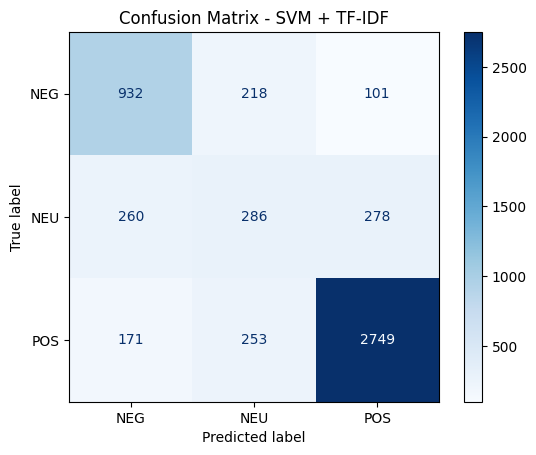

In [33]:
svm_pred = svm_model.predict(X_test)

svm_result = evaluate_model(y_test, svm_pred, "SVM + TF-IDF")

# Phần B — Mô hình PhoBERT với CUDA/GPU

## 12. Chuẩn bị tokenizer PhoBERT

PhoBERT yêu cầu dữ liệu tiếng Việt nên được tách từ trước.
Vì vậy ta sử dụng `tokenized_content`.

In [34]:
MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

## 13. Tạo Dataset class cho PhoBERT

In [38]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

## 14. Tạo DataLoader

In [39]:
MAX_LEN = 128
BATCH_SIZE = 32

train_dataset = SentimentDataset(X_train, y_train, tokenizer, max_len=MAX_LEN)
test_dataset = SentimentDataset(X_test, y_test, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Số batch train:", len(train_loader))
print("Số batch test:", len(test_loader))

Số batch train: 656
Số batch test: 164


## 15. Load mô hình PhoBERT

In [40]:
phobert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

phobert_model.to(device)
print("PhoBERT đã được đưa lên:", device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

PhoBERT đã được đưa lên: cuda


## 16. Cấu hình optimizer

In [41]:
optimizer = AdamW(
    phobert_model.parameters(),
    lr=2e-5
)

EPOCHS = 5

## 17. Huấn luyện PhoBERT

Quá trình này nên chạy bằng GPU.
Nếu chạy CPU, thời gian huấn luyện sẽ rất lâu.

In [ ]:
train_losses = []

for epoch in range(EPOCHS):
    phobert_model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = phobert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {avg_loss:.4f}")

Epoch 1/5: 100%|██████████| 656/656 [07:23<00:00,  1.48it/s, loss=0.387]


Epoch 1/5 - Loss: 0.5901


Epoch 2/5: 100%|██████████| 656/656 [07:27<00:00,  1.47it/s, loss=0.56]


Epoch 2/5 - Loss: 0.4953


Epoch 3/5: 100%|██████████| 656/656 [07:27<00:00,  1.46it/s, loss=0.404]


Epoch 3/5 - Loss: 0.4546


Epoch 4/5: 100%|██████████| 656/656 [07:27<00:00,  1.47it/s, loss=0.488]


Epoch 4/5 - Loss: 0.4307


Epoch 5/5: 100%|██████████| 656/656 [07:27<00:00,  1.47it/s, loss=0.219]

Epoch 5/5 - Loss: 0.3910


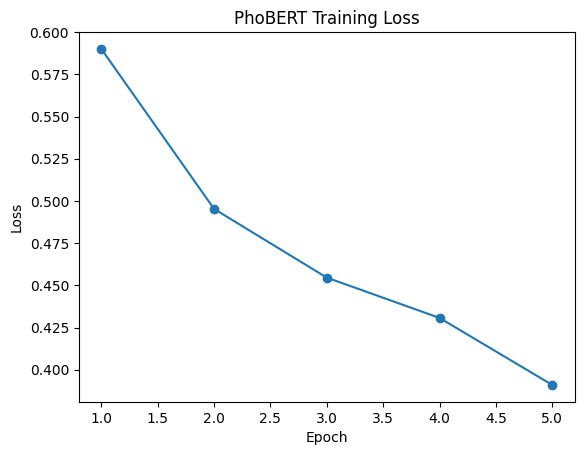

In [43]:
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.title("PhoBERT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 18. Đánh giá PhoBERT

Evaluating PhoBERT: 100%|██████████| 164/164 [00:35<00:00,  4.63it/s]

===== PhoBERT =====
Accuracy : 0.7953506097560976
Precision: 0.777497913290231
Recall   : 0.7953506097560976
F1-score : 0.7844649412641239

Classification Report:
              precision    recall  f1-score   support

         NEG       0.78      0.75      0.76      1251
         NEU       0.42      0.32      0.37       824
         POS       0.87      0.94      0.90      3173

    accuracy                           0.80      5248
   macro avg       0.69      0.67      0.68      5248
weighted avg       0.78      0.80      0.78      5248



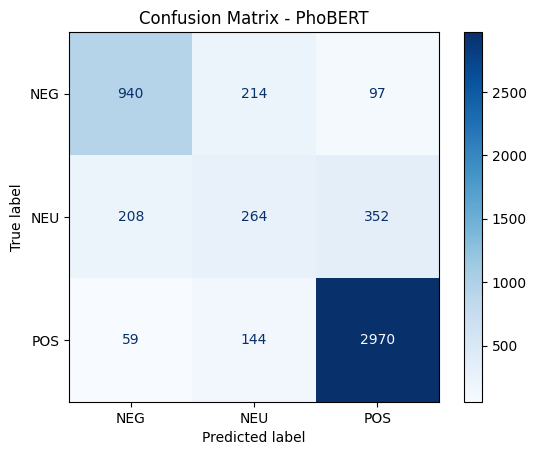

In [44]:
phobert_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating PhoBERT"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = phobert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

phobert_result = evaluate_model(all_labels, all_preds, "PhoBERT")

# Phần C — Mô hình BiLSTM + Word Embedding

BiLSTM được thêm vào như một mô hình trung gian giữa SVM và PhoBERT:

```text
SVM        : mô hình Machine Learning truyền thống
BiLSTM     : mô hình Deep Learning tuần tự
PhoBERT    : mô hình Transformer pretrained cho tiếng Việt
```

Pipeline của BiLSTM:

```text
tokenized_text
→ Vocabulary
→ Convert text to sequence ID
→ Padding
→ Embedding Layer
→ BiLSTM hai chiều
→ Fully Connected Layer
→ Dự đoán NEG / NEU / POS
```

## 19. Import và chuẩn bị vocabulary cho BiLSTM

In [45]:
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F

def build_vocab(texts, max_vocab=30000, min_freq=2):
    counter = Counter()

    for text in texts:
        counter.update(str(text).split())

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)

    return vocab


def text_to_ids(text, vocab, max_len=100):
    tokens = str(text).split()[:max_len]
    return [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]


LSTM_MAX_LEN = 100
LSTM_MAX_VOCAB = 30000
LSTM_MIN_FREQ = 2

lstm_vocab = build_vocab(
    X_train,
    max_vocab=LSTM_MAX_VOCAB,
    min_freq=LSTM_MIN_FREQ
)

VOCAB_SIZE = len(lstm_vocab)

print("Kích thước vocabulary BiLSTM:", VOCAB_SIZE)

Kích thước vocabulary BiLSTM: 3959


## 20. Tạo Dataset và DataLoader cho BiLSTM

In [46]:
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids = text_to_ids(
            self.texts[idx],
            self.vocab,
            max_len=self.max_len
        )

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


def lstm_collate_fn(batch):
    input_ids = [item["input_ids"] for item in batch]
    labels = torch.stack([item["labels"] for item in batch])

    input_ids = pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=lstm_vocab["<PAD>"]
    )

    return {
        "input_ids": input_ids,
        "labels": labels
    }


LSTM_BATCH_SIZE = 64

lstm_train_dataset = LSTMDataset(
    X_train,
    y_train,
    lstm_vocab,
    max_len=LSTM_MAX_LEN
)

lstm_test_dataset = LSTMDataset(
    X_test,
    y_test,
    lstm_vocab,
    max_len=LSTM_MAX_LEN
)

lstm_train_loader = DataLoader(
    lstm_train_dataset,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=True,
    collate_fn=lstm_collate_fn
)

lstm_test_loader = DataLoader(
    lstm_test_dataset,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False,
    collate_fn=lstm_collate_fn
)

print("Số batch train BiLSTM:", len(lstm_train_loader))
print("Số batch test BiLSTM:", len(lstm_test_loader))

Số batch train BiLSTM: 328
Số batch test BiLSTM: 82


## 21. Định nghĩa kiến trúc BiLSTM

Mô hình gồm:

- `Embedding`: biến mỗi token thành vector số.
- `BiLSTM`: học ngữ cảnh theo cả chiều trái → phải và phải → trái.
- `Dropout`: giảm overfitting.
- `Linear`: phân loại thành 3 lớp cảm xúc.

In [47]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=256,
        num_layers=2,
        num_classes=3,
        dropout=0.3
    ):
        super(BiLSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        embedded = self.dropout(embedded)

        outputs, (hidden, cell) = self.lstm(embedded)

        # hidden có shape: [num_layers * 2, batch_size, hidden_dim]
        # Lấy hidden state cuối cùng của chiều forward và backward.
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        final_hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden)

        return logits


bilstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    num_classes=3,
    dropout=0.3
).to(device)

print(bilstm_model)

total_params = sum(p.numel() for p in bilstm_model.parameters())
print("Tổng số tham số BiLSTM:", f"{total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(3959, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)
Tổng số tham số BiLSTM: 2,875,779


## 22. Huấn luyện BiLSTM

Sử dụng:

- `CrossEntropyLoss` cho bài toán phân loại đa lớp.
- `Adam` optimizer.
- `clip_grad_norm_` để hạn chế gradient exploding trong LSTM.

In [48]:
lstm_optimizer = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=2e-3
)

lstm_criterion = nn.CrossEntropyLoss()

LSTM_EPOCHS = 10

lstm_train_losses = []
lstm_train_accuracies = []

for epoch in range(LSTM_EPOCHS):
    bilstm_model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(
        lstm_train_loader,
        desc=f"BiLSTM Epoch {epoch + 1}/{LSTM_EPOCHS}"
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        lstm_optimizer.zero_grad()

        logits = bilstm_model(input_ids)

        loss = lstm_criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            bilstm_model.parameters(),
            max_norm=1.0
        )

        lstm_optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct / total:.4f}"
        })

    avg_loss = total_loss / len(lstm_train_loader)
    train_acc = correct / total

    lstm_train_losses.append(avg_loss)
    lstm_train_accuracies.append(train_acc)

    print(
        f"Epoch {epoch + 1}/{LSTM_EPOCHS} "
        f"- Loss: {avg_loss:.4f} "
        f"- Train Acc: {train_acc:.4f}"
    )

BiLSTM Epoch 1/10: 100%|██████████| 328/328 [00:07<00:00, 46.26it/s, loss=0.5206, acc=0.7116]


Epoch 1/10 - Loss: 0.6815 - Train Acc: 0.7116


BiLSTM Epoch 2/10: 100%|██████████| 328/328 [00:06<00:00, 48.51it/s, loss=0.6620, acc=0.7673]


Epoch 2/10 - Loss: 0.5643 - Train Acc: 0.7673


BiLSTM Epoch 3/10: 100%|██████████| 328/328 [00:06<00:00, 48.20it/s, loss=0.5253, acc=0.7894]


...

Epoch 8/10 - Loss: 0.3441 - Train Acc: 0.8616


BiLSTM Epoch 9/10: 100%|██████████| 328/328 [00:06<00:00, 49.66it/s, loss=0.2176, acc=0.8751]


Epoch 9/10 - Loss: 0.3118 - Train Acc: 0.8751


BiLSTM Epoch 10/10: 100%|██████████| 328/328 [00:08<00:00, 36.98it/s, loss=0.3290, acc=0.8855]

Epoch 10/10 - Loss: 0.2859 - Train Acc: 0.8855


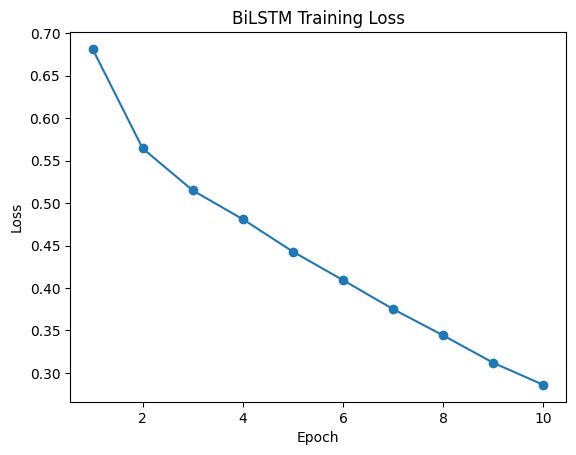

In [49]:
plt.plot(
    range(1, LSTM_EPOCHS + 1),
    lstm_train_losses,
    marker="o"
)

plt.title("BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Evaluating BiLSTM: 100%|██████████| 82/82 [00:00<00:00, 125.90it/s]


===== BiLSTM =====
Accuracy : 0.7648628048780488
Precision: 0.7427860001713392
Recall   : 0.7648628048780488
F1-score : 0.7515966028476646

Classification Report:
              precision    recall  f1-score   support

         NEG       0.71      0.72      0.71      1251
         NEU       0.37      0.26      0.31       824
         POS       0.85      0.91      0.88      3173

    accuracy                           0.76      5248
   macro avg       0.65      0.63      0.63      5248
weighted avg       0.74      0.76      0.75      5248



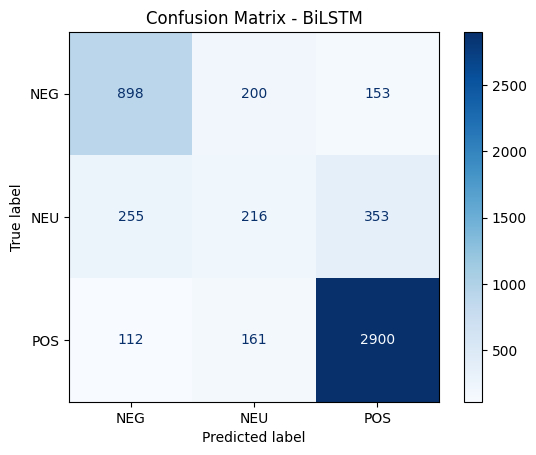

In [50]:
bilstm_model.eval()

bilstm_preds = []
bilstm_labels = []

with torch.no_grad():
    for batch in tqdm(lstm_test_loader, desc="Evaluating BiLSTM"):
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits = bilstm_model(input_ids)

        preds = torch.argmax(logits, dim=1)

        bilstm_preds.extend(preds.cpu().numpy())
        bilstm_labels.extend(labels.cpu().numpy())

bilstm_result = evaluate_model(
    bilstm_labels,
    bilstm_preds,
    "BiLSTM"
)

# Phần D — So sánh kết quả thực nghiệm

In [52]:
results_df = pd.DataFrame([svm_result, phobert_result, bilstm_result])
results_df

,model,accuracy,precision,recall,f1_score
0,SVM + TF-IDF,0.755907,0.753673,0.755907,0.754348
1,PhoBERT,0.795351,0.777498,0.795351,0.784465
2,BiLSTM,0.764863,0.742786,0.764863,0.751597


### 23. So sánh kết quả của tất cả các mô hình

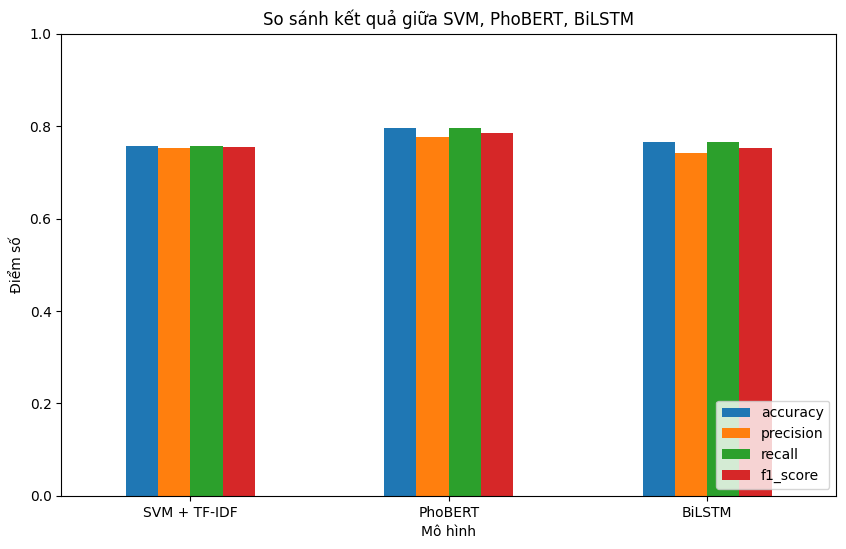

In [53]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", figsize=(10, 6))
plt.title("So sánh kết quả giữa SVM, PhoBERT, BiLSTM")
plt.xlabel("Mô hình")
plt.ylabel("Điểm số")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 24. Nhận xét thực nghiệm

Gợi ý viết báo cáo:

- **SVM + TF-IDF** là mô hình baseline mạnh cho phân loại văn bản.
- SVM có tốc độ huấn luyện nhanh hơn, dễ triển khai hơn.
- Tuy nhiên SVM phụ thuộc vào đặc trưng TF-IDF nên chưa hiểu sâu ngữ cảnh câu.
- **PhoBERT** tận dụng mô hình ngôn ngữ tiền huấn luyện cho tiếng Việt.
- PhoBERT có khả năng hiểu ngữ cảnh tốt hơn, đặc biệt với các câu đánh giá ngắn, cảm xúc không rõ ràng.
- Đổi lại, PhoBERT cần GPU/CUDA và thời gian huấn luyện lâu hơn.

# Phần E — Lưu mô hình và dự đoán thử

## 25. Lưu mô hình

In [55]:
os.makedirs("models", exist_ok=True)

joblib.dump(svm_model, "models/svm_model.pkl")

torch.save(
    {
        "model_state_dict": bilstm_model.state_dict(),
        "vocab": lstm_vocab,
        "label2id": label2id,
        "id2label": id2label,
        "max_len": LSTM_MAX_LEN
    },
    "models/bilstm_model.pt"
)

phobert_model.save_pretrained("models/phobert_model")
tokenizer.save_pretrained("models/phobert_model")

print("Đã lưu SVM, BiLSTM và PhoBERT.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu SVM, BiLSTM và PhoBERT.


## 26. Hàm dự đoán với SVM

In [61]:
def predict_svm(text):
    text = preprocess_text(text)
    pred = svm_model.predict([text])[0]
    return id2label[pred]

test_texts = [
    "Sản phẩm rất tuyệt vời, tôi rất hài lòng!",
    "Hàng không đúng như mô tả, rất thất vọng.",
    "Hàng bình thường, không có gì đặc biệt."
]
for text in test_texts:
    print("Text:", text)
    print("SVM  :", predict_svm(text))
    print()

Text: Sản phẩm rất tuyệt vời, tôi rất hài lòng!
SVM  : POS

Text: Hàng không đúng như mô tả, rất thất vọng.
SVM  : NEG

Text: Hàng bình thường, không có gì đặc biệt.
SVM  : NEU



## 27. Hàm dự đoán với PhoBERT

In [62]:
def predict_phobert(text):
    phobert_model.eval()

    text = preprocess_text(text)

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = phobert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    pred = torch.argmax(outputs.logits, dim=1).item()
    return id2label[pred]

test_texts = [
    "Sản phẩm rất tuyệt vời, tôi rất hài lòng!",
    "Hàng không đúng như mô tả, rất thất vọng.",
    "Hàng bình thường, không có gì đặc biệt."
]
for text in test_texts:
    print("Text:", text)
    print("PhoBERT  :", predict_phobert(text))
    print()

Text: Sản phẩm rất tuyệt vời, tôi rất hài lòng!
PhoBERT  : POS

Text: Hàng không đúng như mô tả, rất thất vọng.
PhoBERT  : NEG

Text: Hàng bình thường, không có gì đặc biệt.
PhoBERT  : NEU



## 27. Hàm dự đoán với BiLSTM

In [57]:
def predict_bilstm(text):
    bilstm_model.eval()

    text = preprocess_text(text)

    ids = text_to_ids(
        text,
        lstm_vocab,
        max_len=LSTM_MAX_LEN
    )

    input_ids = torch.tensor(
        [ids],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():
        logits = bilstm_model(input_ids)

    pred = torch.argmax(logits, dim=1).item()

    return id2label[pred]


test_texts = [
    "Sản phẩm rất tuyệt vời, tôi rất hài lòng!",
    "Hàng không đúng như mô tả, rất thất vọng.",
    "Hàng bình thường, không có gì đặc biệt."
]

for text in test_texts:
    print("Text:", text)
    print("BiLSTM  :", predict_bilstm(text))
    print()

Text: Sản phẩm rất tuyệt vời, tôi rất hài lòng!
BiLSTM  : POS

Text: Hàng không đúng như mô tả, rất thất vọng.
BiLSTM  : NEG

Text: Hàng bình thường, không có gì đặc biệt.
BiLSTM  : POS



## 28. Kết luận

Notebook này đã xây dựng pipeline đầy đủ cho bài toán phân tích cảm xúc đánh giá sản phẩm tiếng Việt với **3 mô hình**:

```text
Load data
→ Kiểm tra dữ liệu
→ Làm sạch dữ liệu
→ Tiền xử lý tiếng Việt: emoji, viết tắt, phủ định, phrase handling
→ Tách từ tiếng Việt bằng PyVi
→ Chia train/test
→ [SVM] TF-IDF + LinearSVC
→ [BiLSTM] Word Embedding + BiLSTM
→ [PhoBERT] Fine-tuning vinai/phobert-base bằng CUDA/GPU
→ Đánh giá Accuracy, Precision, Recall, F1-score
→ So sánh kết quả thực nghiệm
→ Lưu mô hình
→ Dự đoán thử
```

### Nhận xét tổng quát

| Mô hình | Vai trò trong thực nghiệm | Ưu điểm | Hạn chế |
|---|---|---|---|
| SVM + TF-IDF | Baseline truyền thống | Nhanh, dễ huấn luyện, hiệu quả với dữ liệu text | Không hiểu sâu ngữ cảnh |
| BiLSTM | Deep Learning tuần tự | Học được quan hệ trước/sau giữa các từ | Cần nhiều dữ liệu hơn SVM, chưa mạnh bằng Transformer |
| PhoBERT | Transformer pretrained tiếng Việt | Hiểu ngữ cảnh tốt nhất, phù hợp tiếng Việt | Huấn luyện chậm hơn, cần GPU |

Với đề tài này, SVM dùng làm mô hình nền, BiLSTM dùng để kiểm tra hiệu quả của deep learning tuần tự, còn PhoBERT là mô hình hiện đại để so sánh mức cải thiện nhờ pretrained language model.